<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 24)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

# criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 0.2891 acc 0.098 | val loss 0.2049 acc 0.141 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 0.1460 acc 0.358 | val loss 0.0950 acc 0.527 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.0861 acc 0.622 | val loss 0.1070 acc 0.671


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.0681 acc 0.710 | val loss 0.0873 acc 0.732 *


...

[ConvNeXt-Tiny] Epoch  14/100 | LR: 5.00e-05 | train loss 0.0173 acc 0.854 | val loss 0.1098 acc 0.846


[ConvNeXt-Tiny] Epoch  15/100 | LR: 5.00e-06 | train loss 0.0129 acc 0.869 | val loss 0.0783 acc 0.854


[ConvNeXt-Tiny] Epoch  16/100 | LR: 5.00e-06 | train loss 0.0146 acc 0.891 | val loss 0.0883 acc 0.871


[ConvNeXt-Tiny] Epoch  17/100 | LR: 5.00e-06 | train loss 0.0116 acc 0.888 | val loss 0.0915 acc 0.861


[ConvNeXt-Tiny] Epoch  18/100 | LR: 5.00e-06 | train loss 0.0068 acc 0.901 | val loss 0.1006 acc 0.871

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 18.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.0554)


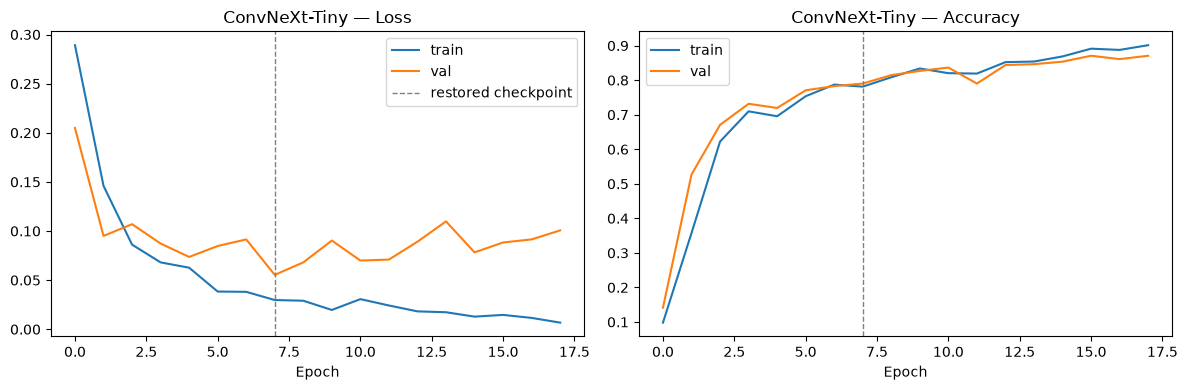

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.798


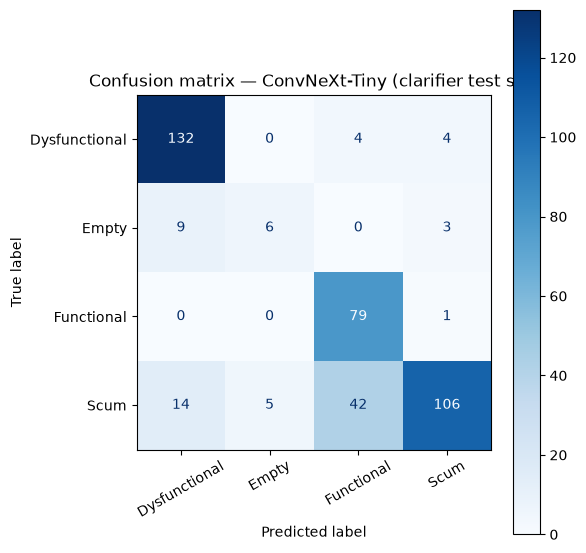

               precision    recall  f1-score   support

Dysfunctional      0.852     0.943     0.895       140
        Empty      0.545     0.333     0.414        18
   Functional      0.632     0.988     0.771        80
         Scum      0.930     0.635     0.754       167

     accuracy                          0.798       405
    macro avg      0.740     0.725     0.708       405
 weighted avg      0.827     0.798     0.791       405



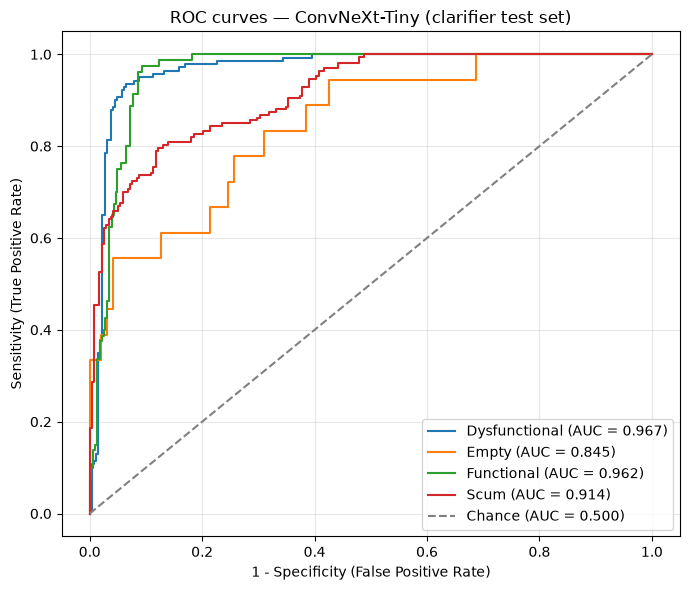

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.967
  Empty          : 0.845
  Functional     : 0.962
  Scum           : 0.914

Mean AUC (over 4/4 classes with test examples): 0.922


(np.float64(0.7975308641975308),
 {'Dysfunctional': 0.9673315363881402,
  'Empty': 0.8452483491243181,
  'Functional': 0.9624615384615385,
  'Scum': 0.9139536053942535})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
